## AUTO ENCODER

In [1]:
import keras
from keras import layers
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import tf2onnx
import onnx
import onnxruntime as ort
import tensorflow as tf

from sklearn.model_selection import train_test_split


#### Create Model

In [26]:
class GumbelSoftmaxBottleneck(layers.Layer):
    def __init__(self, latent_space, **kwargs):
        super(GumbelSoftmaxBottleneck, self).__init__(**kwargs)
        self.latent_space = latent_space
        self.temperature = tf.Variable(1.0, trainable=False, dtype=tf.float32)
        # Define the projection layer here so Keras tracks its weights smoothly
        self.logit_projection = layers.Dense(self.latent_space * 2)

    def call(self, inputs, training=None):
        # 1. Project upstream features into 2 logits per target bit
        logits = self.logit_projection(inputs)
        logits = tf.reshape(logits, (-1, self.latent_space, 2))
        
        if training:
            # Random Gumbel distribution perturbation
            u = tf.random.uniform(tf.shape(logits), minval=0.0, maxval=1.0)
            gumbel_noise = -tf.math.log(-tf.math.log(u + 1e-20) + 1e-20)
            
            # Smooth relaxation approximation pass
            soft_samples = tf.nn.softmax((logits + gumbel_noise) / self.temperature, axis=-1)
            return soft_samples[:, :, 1]  # Return the probability of the bit being '1'
        else:
            # Production execution pass (ONNX Engine mode): Hard discrete choice
            hard_choices = tf.argmax(logits, axis=-1)
            return tf.cast(hard_choices, tf.float32)

In [28]:
class TemperatureAnnealingCallback(keras.callbacks.Callback):
    def __init__(self, bottleneck_layer, decay_rate=0.85, min_temp=0.1):
        super(TemperatureAnnealingCallback, self).__init__()
        self.bottleneck_layer = bottleneck_layer
        self.decay_rate = decay_rate
        self.min_temp = min_temp

    def on_epoch_end(self, epoch, logs=None):
        # Cool down the temperature exponentially at the end of each epoch
        old_temp = float(self.bottleneck_layer.temperature.numpy())
        new_temp = max(self.min_temp, old_temp * self.decay_rate)
        self.bottleneck_layer.temperature.assign(new_temp)
        print(f" -> Epoch {epoch+1}: Gumbel Temperature cooled from {old_temp:.3f} to {new_temp:.3f}")

In [29]:
def autoencoder_training(latent_space, x_train, x_validation, batch=256, logs=1):
    # Encoder
    encoder_inputs = layers.Input(shape=(136,))
    x = layers.Dense(128, activation="relu")(encoder_inputs)
    x = layers.Dense(64, activation="relu")(x)
    encoded = layers.Dense(latent_space, activation="linear")(x)

    encoder = keras.Model(encoder_inputs, encoded, name="Encoder")

    # Decoder
    decoder_input = layers.Input(shape=(latent_space,))
    y = layers.Dense(64, activation="relu")(decoder_input)
    y = layers.Dense(128, activation="relu")(y)
    output = layers.Dense(136, activation="sigmoid")(y)

    decoder = keras.Model(decoder_input, output, name="Decoder")

    # Autoencoder
    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = keras.Model(encoder_inputs, autoencoder_outputs, name="Autoencoder")

    autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.AUC(name="roc_auc", curve="ROC")
        ]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True
    )
        
    history = autoencoder.fit(
        x_train, x_train,
        epochs=20,  # Max epochs, early stopping will cut this short
        batch_size=batch,
        validation_data=(x_validation, x_validation),
        callbacks=[early_stop],
        verbose=logs
    )

    return history, encoder

In [30]:
def binary_autoencoder_training(latent_space, x_train, x_validation, batch=256, logs=1):
    # --- ENCODER ---
    encoder_inputs = layers.Input(shape=(136,))
    x = layers.Dense(128, activation="relu")(encoder_inputs)
    x = layers.Dense(64, activation="relu")(x)
    
    # Sigmoid squeezes numbers between 0 and 1 so they are ready to be binarized
    gumbel_bottleneck = GumbelSoftmaxBottleneck(latent_space=latent_space, name="Gumbel_Bottleneck")
    encoded = gumbel_bottleneck(x)

    encoder = keras.Model(encoder_inputs, encoded, name="Encoder")

    # --- DECODER ---
    decoder_input = layers.Input(shape=(latent_space,))
    y = layers.Dense(64, activation="relu")(decoder_input)
    y = layers.Dense(128, activation="relu")(y)
    output = layers.Dense(136, activation="sigmoid")(y)

    decoder = keras.Model(decoder_input, output, name="Decoder")

    # --- AUTOENCODER CONTAINER ---
    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = keras.Model(encoder_inputs, autoencoder_outputs, name="Autoencoder")

    autoencoder.compile(
        optimizer="adam", 
        loss="binary_crossentropy", 
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.AUC(name="roc_auc", curve="ROC")
        ]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True
    )
        
    history = autoencoder.fit(
        x_train, x_train,
        epochs=20,  
        batch_size=batch,
        validation_data=(x_validation, x_validation),
        callbacks=[early_stop],
        verbose=logs
    )

    return history, encoder

In [ ]:
def deep_canonical_autoencoder_training(latent_space=15, x_train=None, x_validation=None, batch=128, logs=1):
    # --- DEEP ENCODER (Matching the paper's 5-layer compression) ---
    encoder_inputs = layers.Input(shape=(136,))
    x = layers.Dense(120, activation="relu")(encoder_inputs)
    x = layers.Dense(85, activation="relu")(x)
    x = layers.Dense(55, activation="relu")(x)
    x = layers.Dense(30, activation="relu")(x)
    
    # The 15-bit Canonical Bottleneck Layer
    gumbel_bottleneck = GumbelSoftmaxBottleneck(latent_space=latent_space, name="Canonical_Encoding")
    encoded = gumbel_bottleneck(x)

    encoder = keras.Model(encoder_inputs, encoded, name="Encoder")

    # --- DEEP DECODER (Symmetrical Expansion) ---
    decoder_input = layers.Input(shape=(latent_space,))
    y = layers.Dense(30, activation="relu")(decoder_input)
    y = layers.Dense(55, activation="relu")(y)
    y = layers.Dense(85, activation="relu")(y)
    y = layers.Dense(120, activation="relu")(y)
    output = layers.Dense(136, activation="sigmoid")(y)

    decoder = keras.Model(decoder_input, output, name="Decoder")

    # --- AUTOENCODER CONTAINER ---
    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = keras.Model(encoder_inputs, autoencoder_outputs, name="Autoencoder")

    autoencoder.compile(
        optimizer="adam", 
        loss="binary_crossentropy", 
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.AUC(name="roc_auc", curve="ROC")
        ]
    )

    anneal_cb = TemperatureAnnealingCallback(gumbel_bottleneck, decay_rate=0.85)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5, # Give the deeper network a bit more room to converge
        restore_best_weights=True
    )
        
    history = autoencoder.fit(
        x_train, x_train,
        epochs=40,  # Deeper networks benefit from slightly more epochs
        batch_size=batch,
        validation_data=(x_validation, x_validation),
        callbacks=[early_stop, anneal_cb],
        verbose=logs
    )

    return history, encoder

#### Load Data Set

In [39]:
cwd = Path(os.getcwd()).parents[3]
file = f"{cwd}\scenarios\sioux-falls\input\synthetic_dataset.csv"
synthetic_df = pd.read_csv(file, dtype={"encoded_string": str}) 

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\akappadia\AppData\Local\Temp\ipykernel_22616\3253621375.py:2: SyntaxWarning: invalid escape sequence '\s'
  file = f"{cwd}\scenarios\sioux-falls\input\synthetic_dataset.csv"


In [40]:
X = np.stack(synthetic_df['encoded_string'].apply(lambda x: np.array(list(x), dtype=np.float32)))

In [41]:
x_train,x_val_test = train_test_split(X, test_size=0.2, shuffle=True, random_state=42)
x_validation, x_test = train_test_split(x_val_test, test_size=0.5, shuffle=True, random_state=42)

#### Train the model

In [ ]:
latent_space = 16

In [ ]:
history = autoencoder_training(latent_space, x_train, x_validation, batch=256, logs=1)

#### Hyperparameter Tuning

In [ ]:
# Parameter configurations
latent_options = [14, 16, 18, 20]
batch_options = [128, 256]

best_val_mae = float('inf')
best_config = {}

# Array to store results, histories, and labels for final plotting
sweep_results = []

for latent_dim in latent_options:
    for batch_size in batch_options:
        print(f"--- Running: Latent Space={latent_dim} | Batch Size={batch_size} ---")
        
        # Train using your network architecture
        history, _ = deep_canonical_autoencoder_training(
            latent_dim, x_train, x_validation, batch=batch_size, logs=0
        )

        final_train_mae = history.history['mae'][-1]
        final_val_mae = history.history['val_mae'][-1]
        epochs_trained = len(history.history['loss'])

        # Track the optimal configuration metrics
        if final_val_mae < best_val_mae:
            best_val_mae = final_val_mae
            best_config = {
                'latent_dim': latent_dim,
                'batch_size': batch_size,
                'epochs': epochs_trained,
                'val_mae': final_val_mae
            }

        # Store the history metrics cleanly for the final subplot grid
        sweep_results.append({
            'latent_dim': latent_dim,
            'batch_size': batch_size,
            'epochs': epochs_trained,
            'train_mae_history': history.history['mae'],
            'val_mae_history': history.history['val_mae']
        })

--- Running: Latent Space=16 | Batch Size=128 ---
 -> Epoch 1: Gumbel Temperature cooled from 1.000 to 0.850
 -> Epoch 2: Gumbel Temperature cooled from 0.850 to 0.723
 -> Epoch 3: Gumbel Temperature cooled from 0.723 to 0.614
 -> Epoch 4: Gumbel Temperature cooled from 0.614 to 0.522
 -> Epoch 5: Gumbel Temperature cooled from 0.522 to 0.444
 -> Epoch 6: Gumbel Temperature cooled from 0.444 to 0.377
 -> Epoch 7: Gumbel Temperature cooled from 0.377 to 0.321
 -> Epoch 8: Gumbel Temperature cooled from 0.321 to 0.272
 -> Epoch 9: Gumbel Temperature cooled from 0.272 to 0.232
 -> Epoch 10: Gumbel Temperature cooled from 0.232 to 0.197
 -> Epoch 11: Gumbel Temperature cooled from 0.197 to 0.167
 -> Epoch 12: Gumbel Temperature cooled from 0.167 to 0.142
 -> Epoch 13: Gumbel Temperature cooled from 0.142 to 0.121
 -> Epoch 14: Gumbel Temperature cooled from 0.121 to 0.103
 -> Epoch 15: Gumbel Temperature cooled from 0.103 to 0.100
 -> Epoch 16: Gumbel Temperature cooled from 0.100 to 0.100

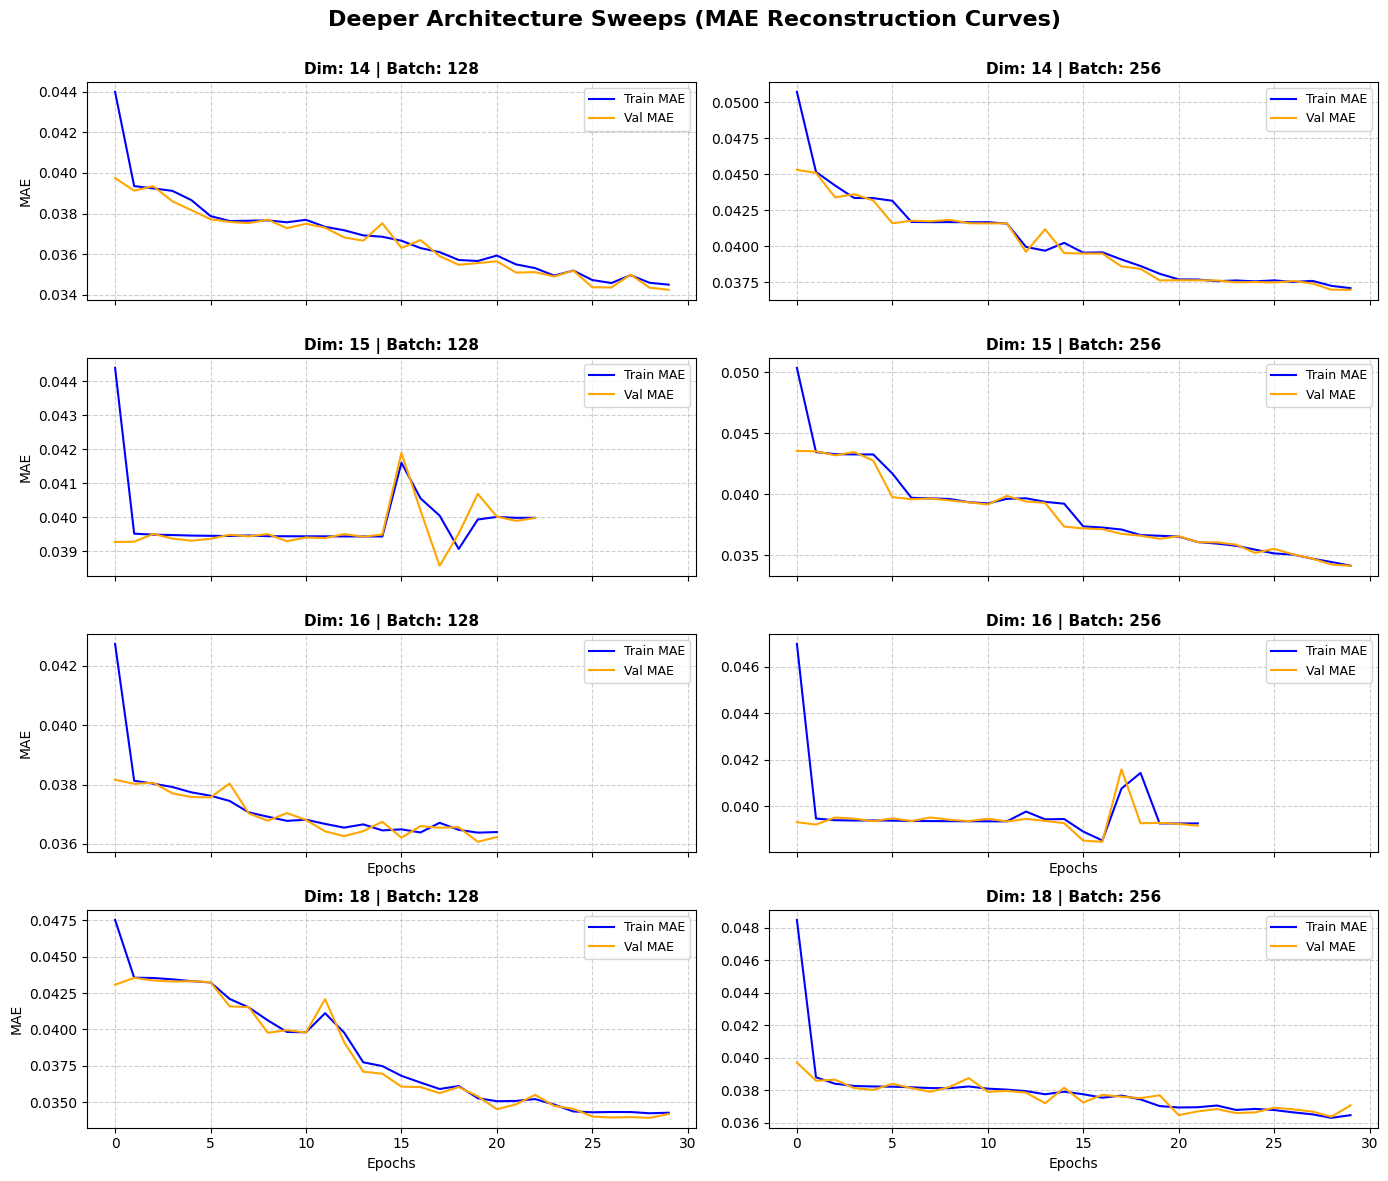

In [23]:
fig, axes = plt.subplots(nrows=len(latent_options), ncols=len(batch_options), figsize=(14, 12), sharex=True)
fig.suptitle("Deeper Architecture Sweeps (MAE Reconstruction Curves)", fontsize=16, fontweight='bold', y=0.98)

axes_flat = axes.flatten()

for plot_idx, result in enumerate(sweep_results):
    ax = axes_flat[plot_idx]
    epoch_axis = np.arange(result['epochs'])
    
    # Plot training metrics cleanly
    ax.plot(epoch_axis, result['train_mae_history'], label="Train MAE", color="blue", linewidth=1.5)
    ax.plot(epoch_axis, result['val_mae_history'], label="Val MAE", color="orange", linewidth=1.5)
    
    # Subplot styling rules
    ax.set_title(f"Dim: {result['latent_dim']} | Batch: {result['batch_size']}", fontsize=11, fontweight='semibold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc="upper right", fontsize=9)
    
    # Label layout boundaries
    if plot_idx >= 4:
        ax.set_xlabel("Epochs", fontsize=10)
    if plot_idx % 2 == 0:
        ax.set_ylabel("MAE", fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Preserve margin space for the layout title
plt.show()

--- Running: Latent Space=10 | Batch Size=128 ---
--- Running: Latent Space=10 | Batch Size=256 ---
--- Running: Latent Space=12 | Batch Size=128 ---
--- Running: Latent Space=12 | Batch Size=256 ---
--- Running: Latent Space=14 | Batch Size=128 ---
--- Running: Latent Space=14 | Batch Size=256 ---


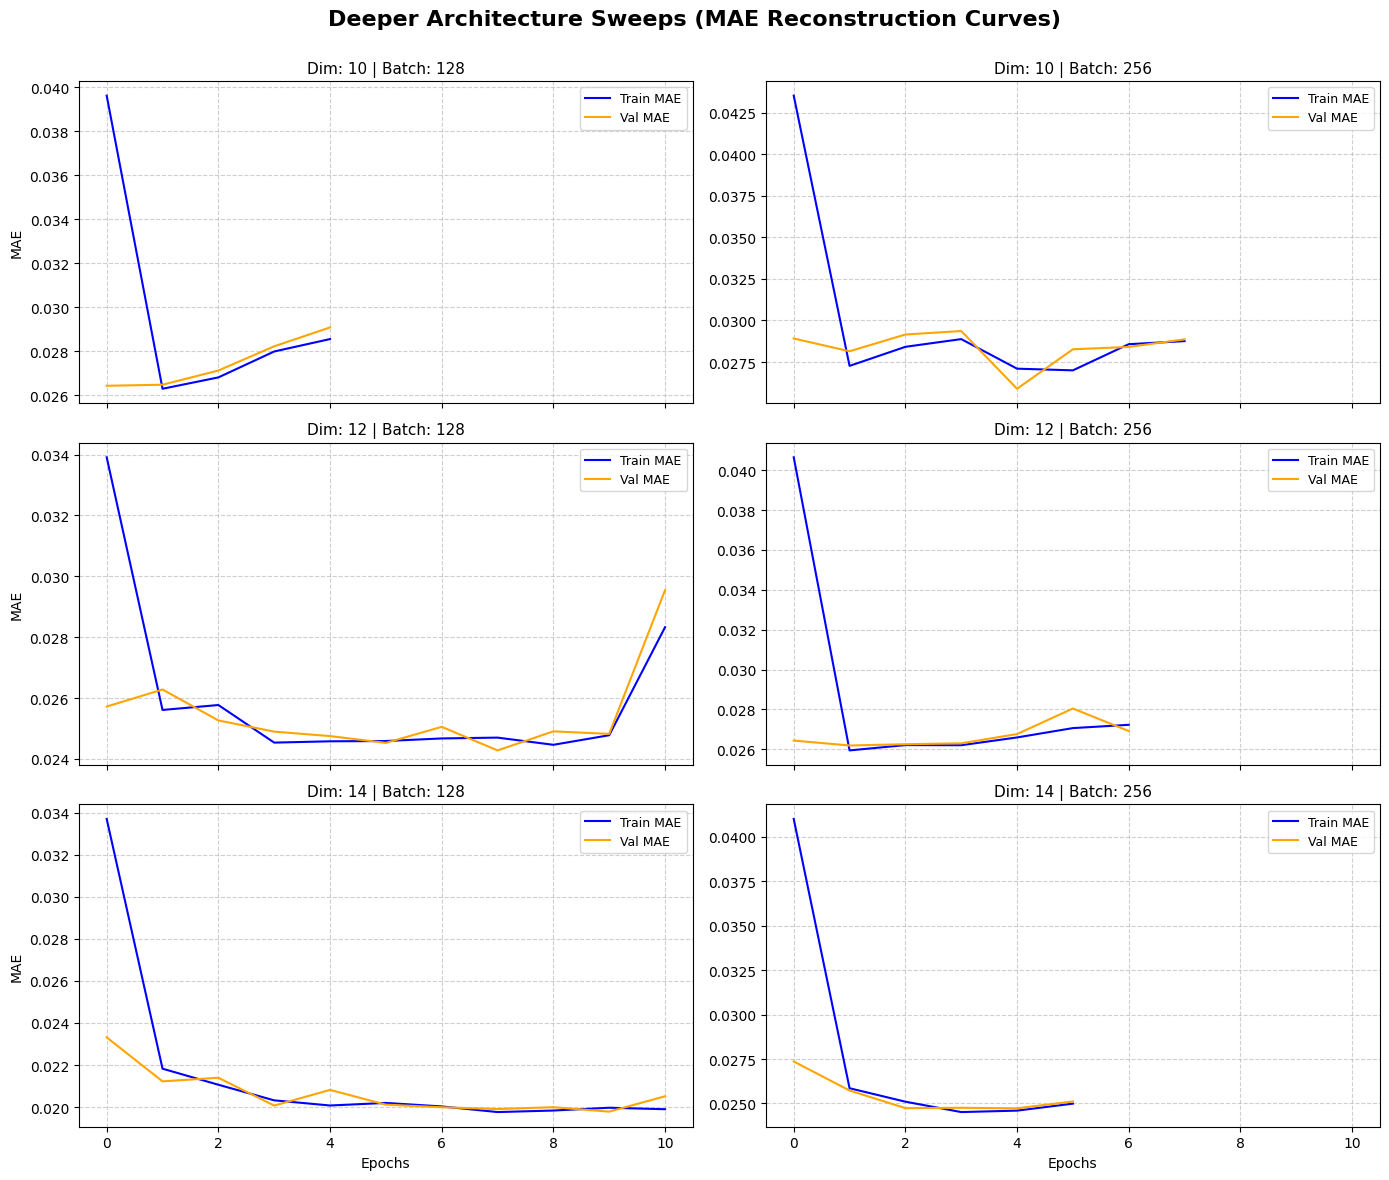

In [10]:
latent_options = [10, 12, 14]
batch_options = [128, 256]

best_val_mae = float('inf')
best_config = {}

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12), sharex=True)
fig.suptitle("Deeper Architecture Sweeps (MAE Reconstruction Curves)", fontsize=16, fontweight='bold', y=0.98)

# Flatten axes array for easy sequential indexing (0 to 5)
axes_flat = axes.flatten()
plot_idx = 0

for latent_dim in latent_options:
    for batch_size in batch_options:
        print(f"--- Running: Latent Space={latent_dim} | Batch Size={batch_size} ---")
        
        # Train using your deeper network architecture
        history, _ = binary_autoencoder_training(
            latent_dim, x_train, x_validation, batch=batch_size, logs=0
        )

        final_train_mae = history.history['mae'][-1]
        final_val_mae = history.history['val_mae'][-1]
        epochs_trained = len(history.history['loss'])

        # Track best overall run
        if final_val_mae < best_val_mae:
            best_val_mae = final_val_mae
            best_config = {
                'latent_dim': latent_dim,
                'batch_size': batch_size,
                'epochs': epochs_trained,
                'val_mae': final_val_mae
            }

        # Select the active subplot axis
        ax = axes_flat[plot_idx]
        epoch_axis = np.arange(epochs_trained)
        
        # Plot curves directly to that specific subplot
        ax.plot(epoch_axis, history.history['mae'], label="Train MAE", color="blue", linewidth=1.5)
        ax.plot(epoch_axis, history.history['val_mae'], label="Val MAE", color="orange", linewidth=1.5)
        
        # Subplot Titles and Styling
        ax.set_title(f"Dim: {latent_dim} | Batch: {batch_size}", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Add labels to the edges of the grid matrix to prevent clutter
        if plot_idx >= 4:
            ax.set_xlabel("Epochs", fontsize=10)
        if plot_idx % 2 == 0:
            ax.set_ylabel("MAE", fontsize=10)
            
        ax.legend(loc="upper right", fontsize=9)
        
        plot_idx += 1

# Automatically adjust spacing so text doesn't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave room for main title
plt.show()


In [32]:
print("\n==========================================")
print(f"-> Latent Dimension: {best_config['latent_dim']}")
print(f"-> Batch Size:       {best_config['batch_size']}")
print(f"-> Epochs Run:       {best_config['epochs']}")
print(f"-> Validation MAE:   {best_config['val_mae']:.6f}")
print("==========================================")


-> Latent Dimension: 20
-> Batch Size:       128
-> Epochs Run:       15
-> Validation MAE:   0.001384


#### Save the encoder as ONNX file format

In [ ]:
_, encoder_model = autoencoder_training(8, x_train, x_validation, batch=256, logs=0)

encoder_model.summary()



Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 151)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,232 (110.28 KB)

 Trainable params: 28,232 (110.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_signature = [tf.TensorSpec(shape=(None, 136), dtype="float32", name="input_136")]

# 3. Convert and save directly to your scenarios folder
onnx_file = f"{cwd}\scenarios\sioux-falls\input\matsim_encoder_dim8.onnx"

model_proto, _ = tf2onnx.convert.from_keras(
    encoder_model, 
    input_signature=input_signature, 
    output_path=onnx_file
)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\akappadia\AppData\Local\Temp\ipykernel_4236\2183986785.py:6: SyntaxWarning: invalid escape sequence '\s'
  onnx_file = f"{cwd}\scenarios\sioux-falls\input\matsim_encoder_dim8.onnx"


In [ ]:
x_test = np.random.randint(0, 2, size=(100, 151)).astype(np.float32)

onnx_file = f"{cwd}\scenarios\sioux-falls\input\matsim_encoder_dim8.onnx"

# Initialize the ONNX Runtime session for inference
session = ort.InferenceSession(onnx_file)
input_name = session.get_inputs()[0].name

# =====================================================================
# CHECK 1: CONSISTENCY TEST (Same input must equal identical output)
# =====================================================================
# Grab the very first state string from your test set
sample_state = np.expand_dims(x_test[0], axis=0)  # Shape: (1, 151)

# Run inference twice on the exact same sample
latent_run_1 = session.run(None, {input_name: sample_state})[0]
latent_run_2 = session.run(None, {input_name: sample_state})[0]

# Check if the outputs match perfectly
is_consistent = np.allclose(latent_run_1, latent_run_2, atol=1e-6)

print("\n--- Check 1: Consistency Verification ---")
print(f"Run 1 Latent Space Vector:\n{latent_run_1[0]}")
print(f"Run 2 Latent Space Vector:\n{latent_run_2[0]}")
if is_consistent:
    print("The encoder is deterministic and perfectly consistent.")
else:
    print("Outputs do not match! Check your runtime environment.")


--- Check 1: Consistency Verification ---
Run 1 Latent Space Vector:
[ -155.90347  -542.13873  -185.4524   -259.38406   314.7453    159.21283
 -1001.6409   -368.19373]
Run 2 Latent Space Vector:
[ -155.90347  -542.13873  -185.4524   -259.38406   314.7453    159.21283
 -1001.6409   -368.19373]
The encoder is deterministic and perfectly consistent.


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\akappadia\AppData\Local\Temp\ipykernel_43336\3807134744.py:3: SyntaxWarning: invalid escape sequence '\s'
  onnx_file = f"{cwd}\scenarios\sioux-falls\input\matsim_encoder_dim8.onnx"


In [ ]:
different_sample_state = np.expand_dims(x_test[1], axis=0)  # Shape: (1, 151)

# Run inference on the second sample
latent_run_different = session.run(None, {input_name: different_sample_state})[0]

# Check if the outputs are unique or if they collapsed to the same numbers
are_identical = np.allclose(latent_run_1, latent_run_different, atol=1e-3)
variance_value = np.var(np.vstack([latent_run_1, latent_run_different]), axis=0)

print("\n--- Check 2: Latent Space Variance Verification ---")
print(f"Different State Latent Vector:\n{latent_run_different[0]}")

if not are_identical:
    print("The encoder successfully maps different states to distinct vectors.")
    print(f"Per-dimension variance between samples:\n{variance_value}")
else:
    print("The model is spitting out the same numbers regardless of input changes.")


--- Check 2: Latent Space Variance Verification ---
Different State Latent Vector:
[-167.51595  -596.70215   -82.95613  -224.3173    213.07516    98.281944
 -923.9731   -342.12115 ]
The encoder successfully maps different states to distinct vectors.
Per-dimension variance between samples:
[  33.71238  744.2916  2626.3708   307.41937 2584.204    928.1432
 1508.0736   169.94473]
